### IMS bearings — EDA

Bearings that failed: `t1b3` inner race, `t1b4` roller element, `t2b1` outer race,
`t3b3` outer race. The other eight finished healthy.

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from phm_101.data_loader import DataLoader

loader = DataLoader()

times, signals = loader.load('t2b1_x')
signals.shape, signals.dtype

((984, 20480), dtype('float32'))

### visualization

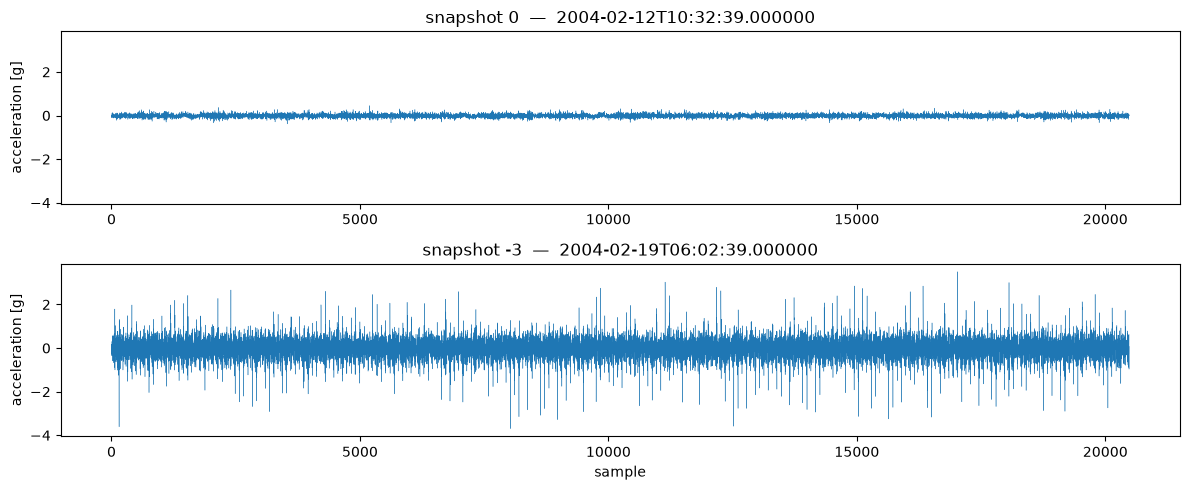

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharey=True)

for ax, i in zip(axes, [0, -3], strict=False):
    ax.plot(signals[i], lw=0.3)
    ax.set_title(f'snapshot {i}  —  {times[i]}')
    ax.set_ylabel('acceleration [g]')

axes[-1].set_xlabel('sample')
fig.tight_layout()

### RMS

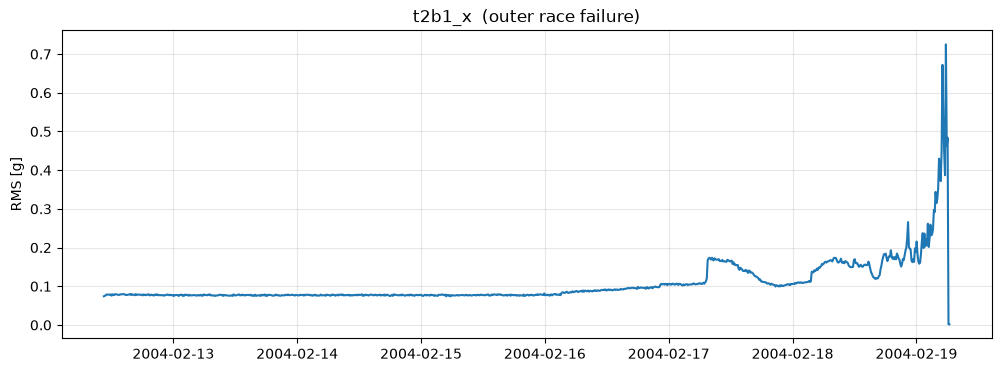

In [4]:
def rms(signals):
    return np.sqrt((signals.astype(np.float64) ** 2).mean(axis=1))


plt.figure(figsize=(12, 4))
plt.plot(times, rms(signals))
plt.ylabel('RMS [g]')
plt.title('t2b1_x  (outer race failure)')
plt.grid(alpha=0.3)

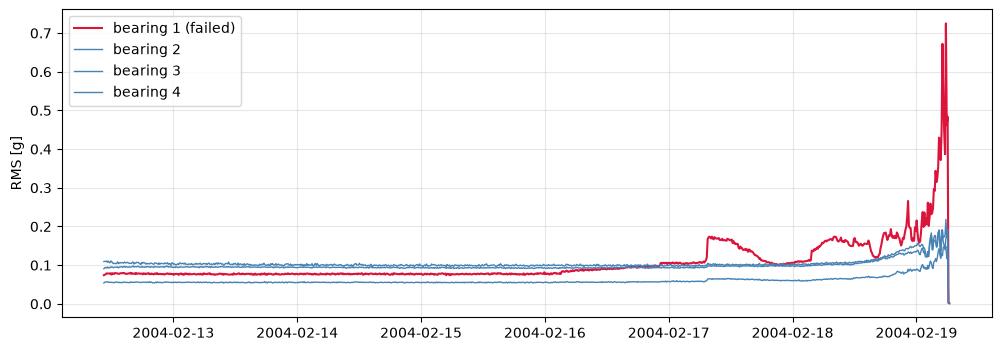

In [5]:
plt.figure(figsize=(12, 4))

for bearing in [1, 2, 3, 4]:
    t, s = loader.load(f't2b{bearing}_x')
    failed = bearing == 1
    plt.plot(
        t,
        rms(s),
        lw=1.5 if failed else 1.0,
        color='crimson' if failed else 'steelblue',
        label=f'bearing {bearing}' + (' (failed)' if failed else ''),
    )

plt.ylabel('RMS [g]')
plt.legend()
plt.grid(alpha=0.3)

Two things to notice:

- The healthy bearings drift upward too — the whole rig shakes harder as bearing 1
  breaks up. So "RMS went up" alone is not enough to blame a bearing.
- The last couple of snapshots drop to nearly zero: the rig was switched off. Those
  are not vibration and should be dropped.

In [ ]:
print(rms(signals)[-5:].round(4))

## How different are the four failures?

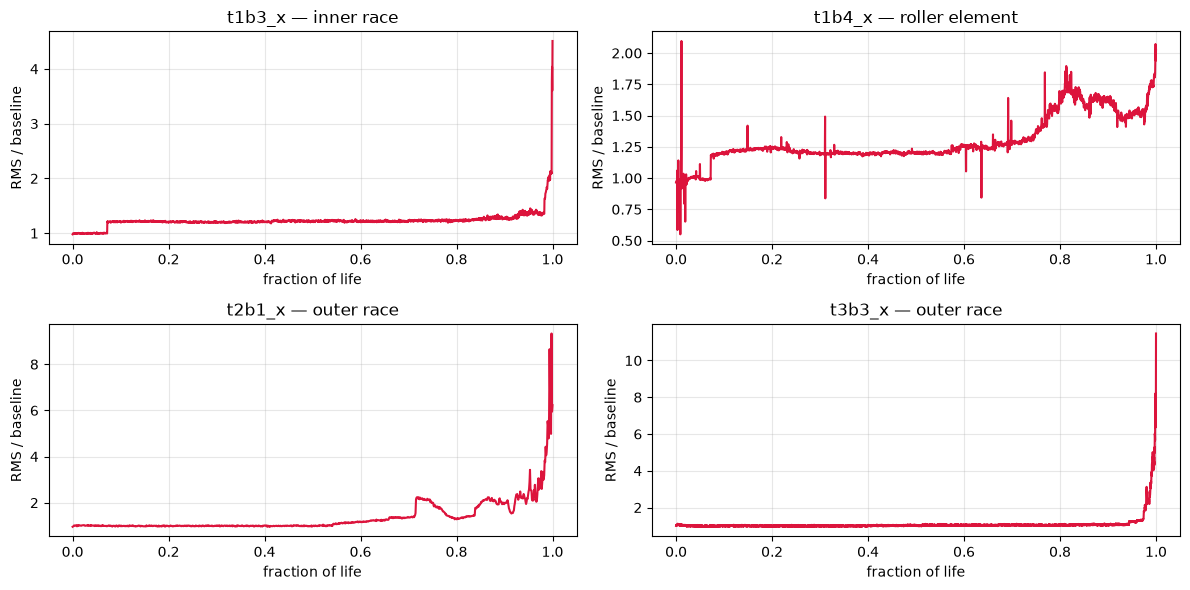

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
faults = {
    't1b3_x': 'inner race',
    't1b4_x': 'roller element',
    't2b1_x': 'outer race',
    't3b3_x': 'outer race',
}

for ax, (name, fault) in zip(axes.ravel(), faults.items()):
    _, s = loader.load(name)
    r = rms(s)
    r = r[r > 0.01]  # drop the rig-off snapshots
    life = np.linspace(0, 1, len(r))
    ax.plot(life, r / np.median(r[: len(r) // 10]), color='crimson')
    ax.set_title(f'{name} — {fault}')
    ax.set_xlabel('fraction of life')
    ax.set_ylabel('RMS / baseline')
    ax.grid(alpha=0.3)

fig.tight_layout()

The four failures look nothing alike. `t2b1` starts climbing about two thirds through
its life, while `t3b3` is flat until ~97% and then explodes.

That is why the detector is trained per bearing on its own healthy start, rather than
with one rule fitted across all of them.